# It worked overall and hurt one segment

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/heterogeneous-effects/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/heterogeneous-effects/demo.ipynb)

Every experiment write-up ends with a segment scan: the same test re-run inside country,
device, tenure and plan, looking for the group the launch hurt. This notebook builds a world
where **nobody is hurt** - one true effect, identical for every user - and then runs the scan
and a CATE tree on it, to see what each one reports.

What it covers:

1. the arithmetic of a scan, and why the version everyone quotes is the wrong one
2. what the worst segment's number is actually an estimate of
3. why the scan is blind by construction, and what naming a segment in advance buys
4. a fitted subgroup whose effect **is** the objective function it was chosen by
5. the one check here with no power problem, because it is algebra rather than a test

Everything runs on synthetic data with a known truth, so every claim is checkable in the cell
that makes it.

## 1. The world, and the two estimators

`trial` draws a randomised test: `n` users, split 50/50, one outcome, and `k` equal
pre-defined segments. The true effect is `ate` for **everybody** unless you pass `delta`,
which harms one segment.

`scan` is the thing under examination: a difference in means with a Welch standard error,
inside every segment.

In [1]:
from __future__ import annotations

from typing import Dict, Optional, Tuple

import numpy as np
from scipy import integrate, stats

ALPHA = 0.05


def trial(rng, n=8000, k=20, ate=0.05, delta=0.0, harmed=0, sigma=1.0):
    """A randomised test with k equal segments. delta harms segment `harmed`."""
    seg = rng.integers(0, k, size=n)
    w = (rng.random(n) < 0.5).astype(np.int8)
    tau = np.full(n, ate)
    if delta:
        tau[seg == harmed] = ate - delta
    y = rng.normal(0.0, sigma, size=n) + w * tau
    return {"seg": seg, "w": w, "y": y, "tau": tau}


def diff_means(y, w) -> Tuple[float, float]:
    y1, y0 = y[w == 1], y[w == 0]
    if y1.size < 2 or y0.size < 2:
        return float("nan"), float("inf")
    est = float(y1.mean() - y0.mean())
    se = float(np.sqrt(y1.var(ddof=1) / y1.size + y0.var(ddof=1) / y0.size))
    return est, se


def scan(y, w, groups) -> Dict[str, np.ndarray]:
    """diff_means inside every column of `groups` (n x G booleans, may overlap)."""
    est = np.empty(groups.shape[1])
    se = np.empty(groups.shape[1])
    for j in range(groups.shape[1]):
        m = groups[:, j]
        est[j], se[j] = diff_means(y[m], w[m])
    with np.errstate(invalid="ignore", divide="ignore"):
        t = est / se
    p = 2.0 * stats.norm.sf(np.abs(t))
    return {"est": est, "se": se, "p": np.where(np.isfinite(p), p, 1.0)}


def parts(seg, k):
    return np.stack([seg == j for j in range(k)], axis=1)


def bonferroni(p):
    return np.minimum(1.0, p * p.size)


def harm_flag(res, alpha=ALPHA, adjust=False) -> bool:
    """Did the scan call at least one segment significantly HARMED?"""
    p = bonferroni(res["p"]) if adjust else res["p"]
    return bool(np.any((res["est"] < 0.0) & (p < alpha)))


def segment_se(n, k, sigma=1.0):
    return float(sigma * np.sqrt(4.0 * k / n))


rng = np.random.default_rng(1)
d = trial(rng, n=8000, k=20, ate=0.05)
res = scan(d["y"], d["w"], parts(d["seg"], 20))
print("true effect, every user       +0.0500")
print(f"overall estimate             {diff_means(d['y'], d['w'])[0]:+.4f}")
print(f"segment SE (measured)        {res['se'].mean():.4f}")
print(f"segment SE (sigma*sqrt(4K/n)) {segment_se(8000, 20):.4f}")
print(f"worst segment reported       {res['est'].min():+.4f}")

true effect, every user       +0.0500
overall estimate             +0.0220
segment SE (measured)        0.0995
segment SE (sigma*sqrt(4K/n)) 0.1000
worst segment reported       -0.2889


## 2. The alarm rate is arithmetic - but not the arithmetic everybody quotes

The familiar line is that 20 segment tests at 0.05 give a family-wise error rate of
`1-(1-0.05)^20 = 64%`, or 40% if you only count flags in the harmful direction. That
expression assumes the true effect is **zero**.

With a real effect, every segment's sampling distribution is shifted away from zero, and the
alarm rate needs the effect in it:

$$P(\text{harm flag}) = 1 - \left(1 - \Phi\!\left(-z_{\alpha/2} - \frac{\tau}{\sigma_{seg}}\right)\right)^{K},
\qquad \sigma_{seg} = \sigma\sqrt{4K/n}$$

The cell below measures it against both forms.

In [2]:
def naive_cf(k, alpha=ALPHA):
    return 1.0 - (1.0 - alpha / 2.0) ** k


def cf_with_effect(k, n, ate, sigma=1.0, alpha=ALPHA):
    se = segment_se(n, k, sigma)
    per = float(stats.norm.cdf(-stats.norm.isf(alpha / 2.0) - ate / se))
    return 1.0 - (1.0 - per) ** k


rng = np.random.default_rng(21)
print(f"{'K':>4} {'true ate':>9} {'measured':>9} {'1-(1-.025)^K':>13} {'with the effect':>16}")
for k, ate in ((20, 0.00), (20, 0.05), (20, 0.10), (50, 0.05)):
    fires = 0
    for _ in range(600):
        d = trial(rng, n=8000, k=k, ate=ate)
        fires += int(harm_flag(scan(d["y"], d["w"], parts(d["seg"], k))))
    print(f"{k:>4} {ate:>9.2f} {fires / 600:>9.3f} {naive_cf(k):>13.3f} {cf_with_effect(k, 8000, ate):>16.3f}")

   K  true ate  measured  1-(1-.025)^K  with the effect
  20      0.00     0.373         0.397            0.397
  20      0.05     0.157         0.397            0.130
  20      0.10     0.033         0.397            0.030
  50      0.05     0.473         0.718            0.437


Two readings, and the second one is the uncomfortable one.

* The quoted number is **3x too big** on a launch that worked (0.397 vs 0.130 at K=20).
* A scan is most exposed to inventing a harmed segment exactly when **the launch did nothing**.
  A strong launch is partly self-protecting. So "it worked overall but hurt segment 7" is
  least trustworthy in precisely the situation people tell that story about.

It also means the false-alarm rate is **not** flat in the sample size, unlike the biases in
this section's earlier builds: $\tau/\sigma_{seg}$ grows with $\sqrt{n}$, so a bigger test
is a safer scan.

## 3. What the worst segment's number is an estimate of

The reported effect in the segment that came out worst is not that segment's effect. It is the
**minimum of K draws**, and the expected minimum of K standard normals is a number you can
compute before collecting any data at all:

$$E[\min Z_K] = \int z \cdot K \phi(z) \Phi(z)^{K-1} dz$$

In [3]:
def expected_min_z(k):
    val, _ = integrate.quad(lambda z: z * k * stats.norm.pdf(z) * stats.norm.cdf(z) ** (k - 1), -12, 12, limit=400)
    return -float(val)


rng = np.random.default_rng(31)
worst, repl, flagged = [], [], []
for _ in range(600):
    d = trial(rng, n=8000, k=20, ate=0.05)
    res = scan(d["y"], d["w"], parts(d["seg"], 20))
    j = int(np.argmin(res["est"]))
    worst.append(res["est"][j])
    flagged.append(res["p"][j] < ALPHA and res["est"][j] < 0)
    d2 = trial(rng, n=8000, k=20, ate=0.05)
    m = d2["seg"] == j
    repl.append(diff_means(d2["y"][m], d2["w"][m])[0])

predicted = 0.05 + segment_se(8000, 20) * expected_min_z(20)
print(f"E[min Z20]                     {expected_min_z(20):+.4f}")
print(f"worst segment, reported        {np.mean(worst):+.4f}")
print(f"worst segment, predicted       {predicted:+.4f}   <- before any data")
print(f"same segment, fresh sample     {np.mean(repl):+.4f}   <- the truth is +0.0500")
print(f"and it is called significant   {np.mean(flagged):.3f} of the time")

E[min Z20]                     -1.8675
worst segment, reported        -0.1335
worst segment, predicted       -0.1367   <- before any data
same segment, fresh sample     +0.0430   <- the truth is +0.0500
and it is called significant   0.113 of the time


The prediction lands on the measurement. Nothing about that segment produced the harm - the
`min` operator produced it, and re-running the same segment returns the truth. This is why
"the harmed segment did not replicate" is the usual epilogue, and why nobody learns anything
from it.

One thing that **does** survive: with a genuinely harmed segment the *ranking* is informative
even where the number is not - the worst segment is the truly harmed one about 88% of the time
at these settings (section 3 of `evidence.py`).

## 4. The scan is blind by construction

A segment holds `n/K` users, so its standard error is `sqrt(K)` times the experiment's. At
K=20 that is 4.47x, and a Bonferroni-corrected segment test is wider again. The consequence is
not subtle: the scan cannot see harms several times larger than the effect the experiment was
sized to detect.

Naming ONE segment before the test - a pre-registered guardrail - costs nothing in power and
deletes section 2 entirely.

In [4]:
rng = np.random.default_rng(41)
print(f"{'harm':>6} {'named in advance':>17} {'scan 20, bonf':>14} {'overall test +ve':>17}")
for delta in (0.10, 0.30, 0.60, 1.00):
    pre = bo = ov = 0
    for _ in range(250):
        d = trial(rng, n=8000, k=20, ate=0.05, delta=delta, harmed=0)
        res = scan(d["y"], d["w"], parts(d["seg"], 20))
        pre += int(res["est"][0] < 0 and res["p"][0] < ALPHA)
        bo += int(res["est"][0] < 0 and bonferroni(res["p"])[0] < ALPHA)
        est, se = diff_means(d["y"], d["w"])
        ov += int(est / se > 1.96)
    print(f"{delta:>6.2f} {pre / 250:>17.3f} {bo / 250:>14.3f} {ov / 250:>17.3f}")

  harm  named in advance  scan 20, bonf  overall test +ve
  0.10             0.080          0.004             0.524
  0.30             0.720          0.292             0.332
  0.60             1.000          0.996             0.140
  1.00             1.000          1.000             0.004


Read the last column too. As the harm grows, the **overall** test stops being significant -
one segment's harm is diluted 1/K, so at a harm of 1.00 the launch is a wash in aggregate
while a twentieth of users lose 0.95. The aggregate test is not a weaker version of the
segment question; it is a different question.

## 5. The fitted subgroup, whose effect is the objective function

The modern answer to a segment scan is to **estimate** the heterogeneity instead of slicing
for it: a causal tree finds the split that separates high-effect from low-effect users. The
signal it splits on is the transformed outcome

$$Y^* = Y\,\frac{W-p}{p(1-p)}, \qquad E[Y^*\mid X] = \tau(X)$$

The tree below is fitted on a world with **no heterogeneity at all** - one covariate matrix,
five useless columns, tau = 0.05 for everyone. Then its worst leaf is scored twice: on the
rows that chose the split, and on a held-out half.

In [5]:
class Node:
    __slots__ = ("feat", "thr", "left", "right", "leaf_id")

    def __init__(self):
        self.feat, self.thr, self.left, self.right, self.leaf_id = -1, 0.0, None, None, -1


def best_split(x, ystar, min_leaf, n_grid=24):
    best, n, total = (0.0, -1, 0.0), ystar.size, ystar.sum()
    if n < 2 * min_leaf:
        return best
    for j in range(x.shape[1]):
        col = x[:, j]
        for thr in np.unique(np.quantile(col, np.linspace(0.05, 0.95, n_grid))):
            m = col <= thr
            n_l = int(m.sum())
            if n_l < min_leaf or n - n_l < min_leaf:
                continue
            s_l = ystar[m].sum()
            gain = s_l * s_l / n_l + (total - s_l) ** 2 / (n - n_l) - total * total / n
            if gain > best[0]:
                best = (float(gain), j, float(thr))
    return best


def causal_tree(x, w, y, depth=2, min_leaf=100, p=0.5):
    ystar = y * (w - p) / (p * (1 - p))
    counter = [0]

    def grow(idx, d):
        node = Node()
        gain, feat, thr = (0.0, -1, 0.0) if d == 0 else best_split(x[idx], ystar[idx], min_leaf)
        if feat < 0 or gain <= 0:
            node.leaf_id = counter[0]
            counter[0] += 1
            return node
        node.feat, node.thr = feat, thr
        m = x[idx, feat] <= thr
        node.left, node.right = grow(idx[m], d - 1), grow(idx[~m], d - 1)
        return node

    return grow(np.arange(x.shape[0]), depth)


def leaf_of(tree, x):
    out = np.empty(x.shape[0], dtype=np.int64)
    for i in range(x.shape[0]):
        node = tree
        while node.leaf_id < 0:
            node = node.left if x[i, node.feat] <= node.thr else node.right
        out[i] = node.leaf_id
    return out


def n_leaves(tree):
    return 1 if tree.leaf_id >= 0 else n_leaves(tree.left) + n_leaves(tree.right)


rng = np.random.default_rng(61)
ins, hon, cov_i, cov_h, sig_i = [], [], [], [], []
for _ in range(120):
    n = 4000
    x = rng.normal(size=(n, 5))
    w = (rng.random(n) < 0.5).astype(np.int8)
    y = 0.5 * x[:, 1] + rng.normal(size=n) + w * 0.05      # tau = 0.05 for EVERYONE
    idx = rng.permutation(n)
    a, b = idx[: n // 2], idx[n // 2 :]
    tree = causal_tree(x[a], w[a], y[a], depth=2, min_leaf=100)
    la, lb = leaf_of(tree, x[a]), leaf_of(tree, x[b])
    g = n_leaves(tree)
    r_in = scan(y[a], w[a], np.stack([la == j for j in range(g)], axis=1))
    r_ho = scan(y[b], w[b], np.stack([lb == j for j in range(g)], axis=1))
    j = int(np.argmin(r_in["est"]))
    ins.append(r_in["est"][j])
    hon.append(r_ho["est"][j])
    cov_i.append(abs(r_in["est"][j] - 0.05) <= 1.96 * r_in["se"][j])
    cov_h.append(abs(r_ho["est"][j] - 0.05) <= 1.96 * r_ho["se"][j])
    sig_i.append(r_in["est"][j] < 0 and r_in["p"][j] < ALPHA)

print(f"worst leaf, scored on its own rows   {np.mean(ins):+.4f}   truth +0.0500")
print(f"worst leaf, scored on held-out rows  {np.mean(hon):+.4f}")
print(f"in-sample CI covers the truth        {np.mean(cov_i):.3f}   <- nominal 0.950")
print(f"honest CI covers the truth           {np.mean(cov_h):.3f}")
print(f"in-sample calls it harmed            {np.mean(sig_i):.3f}   of runs, on a world with no harm")

worst leaf, scored on its own rows   -0.2719   truth +0.0500
worst leaf, scored on held-out rows  +0.0337
in-sample CI covers the truth        0.383   <- nominal 0.950
honest CI covers the truth           0.975
in-sample calls it harmed            0.525   of runs, on a world with no harm


A subgroup that **does not exist** is reported as significantly harmed by about half of these
runs, with an interval that covers the truth a third of the time.

The tree is not misbehaving. It was asked for the split that maximises the difference in the
effect signal; reading the effect off the same rows is reading the objective function back
out. That is the same failure the previous build found in a synthetic control's pre-period
fit - a different fitted object, an identical mechanism - and the fix has the same shape:
**score the thing on data that did not choose it**.

## 6. The one check with no power problem

Every guard in this section's builds has ended the same way: calibrated, cheap, and blind to
the failure it was built for. Here is the exception, and the reason it works is that it is not
a statistical test at all.

For a partition fixed **before** assignment, the share-weighted mean of the segment effects
equals the overall effect up to `O(1/n)`. Condition on something measured **after**
assignment - "engaged users", "users who opened the email" - and the identity breaks. No
counterfactual, no assumption, and nobody runs it.

In [6]:
def consistency_gap(y, w, groups):
    """(share-weighted mean of segment effects - overall effect), in overall SEs."""
    overall, se = diff_means(y, w)
    res = scan(y, w, groups)
    share = groups.sum(axis=0) / groups.shape[0]
    ok = np.isfinite(res["est"])
    inner = float(np.sum(share[ok] * res["est"][ok]) / np.sum(share[ok]))
    return (inner - overall) / se


rng = np.random.default_rng(71)
legit, broken, eng, non, whole = [], [], [], [], []
for _ in range(150):
    n = 20000
    d = trial(rng, n=n, k=2, ate=0.05)
    legit.append(consistency_gap(d["y"], d["w"], parts(d["seg"], 2)))

    latent = rng.normal(size=n)
    w = (rng.random(n) < 0.5).astype(np.int8)
    engaged = latent + 0.30 * w > 0                       # measured AFTER assignment
    y = 0.8 * latent + rng.normal(size=n) + w * 0.05      # tau = 0.05 for EVERYONE
    g = np.stack([engaged, ~engaged], axis=1)
    broken.append(consistency_gap(y, w, g))
    eng.append(diff_means(y[engaged], w[engaged])[0])
    non.append(diff_means(y[~engaged], w[~engaged])[0])
    whole.append(diff_means(y, w)[0])

print(f"'engaged users' segment       {np.mean(eng):+.4f}")
print(f"'not engaged' segment         {np.mean(non):+.4f}")
print(f"everybody                     {np.mean(whole):+.4f}   <- the truth, +0.0500")
print()
print(f"gap, pre-assignment split     {np.mean(legit):+.5f}  sd {np.std(legit):.5f}")
print(f"gap, post-assignment split    {np.mean(broken):+.5f}  sd {np.std(broken):.5f}")
print(f"separation                    {abs(np.mean(broken)) / np.std(legit):.0f} legit-sd")

'engaged users' segment       -0.0951
'not engaged' segment         -0.1115
everybody                     +0.0498   <- the truth, +0.0500

gap, pre-assignment split     +0.00135  sd 0.00804
gap, post-assignment split    -8.39316  sd 0.49896
separation                    1043 legit-sd


Both parts say the launch hurt while the whole says it helped. For a real partition that is
arithmetically impossible, which is exactly what makes it detectable - and the gap separates
the two worlds by a factor of about a thousand, with no threshold tuning and no power curve.

A guard that checks an accounting identity beats a guard that estimates a parameter, whenever
you can find one.

## 7. One picture

Left: the scan on a homogeneous world - the true effect is the same flat line for every
segment, and the extremes are selection. Right: the same two numbers from the fitted
subgroup, in-sample and honest.

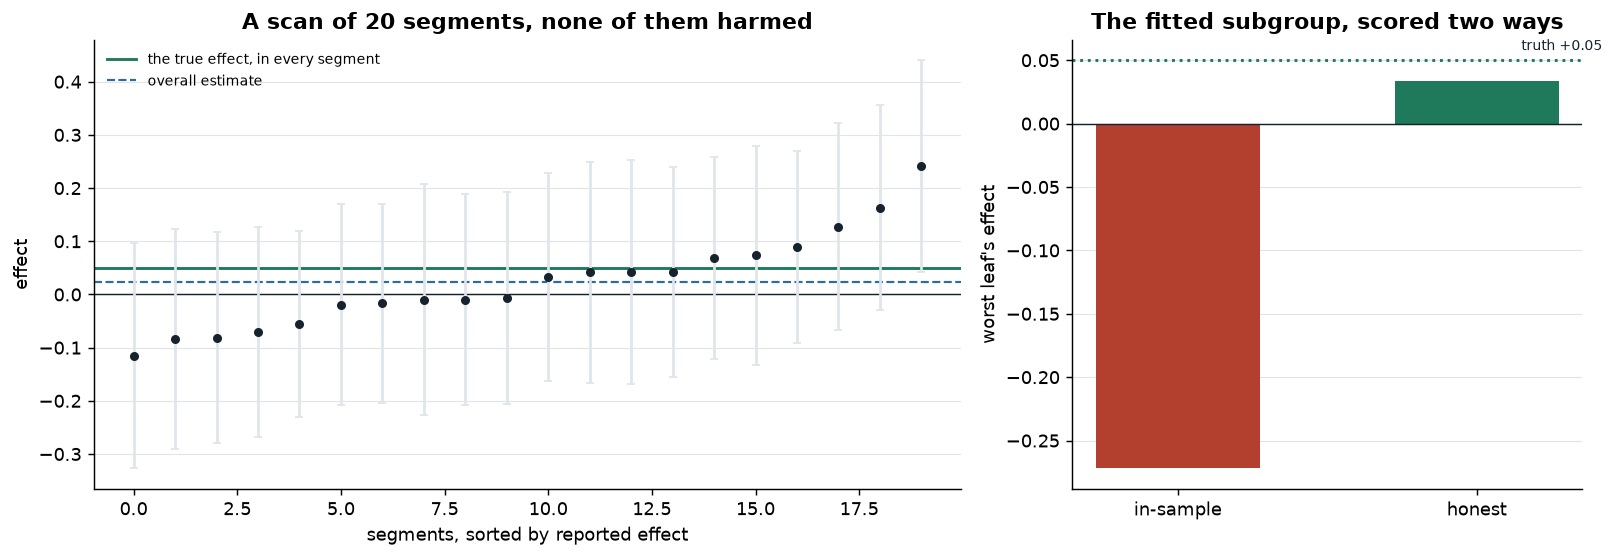

In [7]:
import matplotlib.pyplot as plt

INK, BAD, COOL, GOOD, GRID = "#16222e", "#b3402f", "#2b6ca3", "#1f7a5c", "#dfe5ea"

rng = np.random.default_rng(99)
d = trial(rng, n=8000, k=20, ate=0.05)
res = scan(d["y"], d["w"], parts(d["seg"], 20))
overall = diff_means(d["y"], d["w"])[0]
order = np.argsort(res["est"])
flag = (res["est"] < 0) & (res["p"] < ALPHA)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4), dpi=130, gridspec_kw={"width_ratios": [1.7, 1]})
xs = np.arange(20)
ax.errorbar(xs, res["est"][order], yerr=1.96 * res["se"][order], fmt="o", ms=4,
            color=INK, ecolor=GRID, capsize=2, zorder=3)
f = flag[order]
if f.any():
    ax.errorbar(xs[f], res["est"][order][f], yerr=1.96 * res["se"][order][f], fmt="o", ms=7,
                color=BAD, ecolor=BAD, capsize=2, zorder=4, label="called harmed (p<0.05)")
ax.axhline(0.05, color=GOOD, lw=1.6, label="the true effect, in every segment")
ax.axhline(0.0, color=INK, lw=0.8)
ax.axhline(overall, color=COOL, ls="--", lw=1.2, label="overall estimate")
ax.set_xlabel("segments, sorted by reported effect")
ax.set_ylabel("effect")
ax.set_title("A scan of 20 segments, none of them harmed", fontweight="bold")
ax.legend(fontsize=8, frameon=False)

ax2.bar(["in-sample", "honest"], [np.mean(ins), np.mean(hon)], 0.55, color=[BAD, GOOD])
ax2.axhline(0.05, color=GOOD, lw=1.6, ls=":")
ax2.axhline(0.0, color=INK, lw=0.8)
ax2.text(1.42, 0.058, "truth +0.05", fontsize=8, ha="right", color=INK)
ax2.set_ylabel("worst leaf's effect")
ax2.set_title("The fitted subgroup, scored two ways", fontweight="bold")

for a in (ax, ax2):
    a.grid(axis="y", color=GRID, lw=0.6)
    a.set_axisbelow(True)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("hte_notebook_figure.png", bbox_inches="tight")
plt.show()

## What this build measured

| | |
|---|---|
| P(a scan of 20 segments invents a harmed one), true effect 0 | **0.406** measured, 0.397 closed form |
| the same, true effect +0.05 with `se_seg` 0.10 | **0.150** measured, 0.130 closed form, and the quoted 0.397 is 3x too big |
| the worst segment's reported effect (truth +0.05) | **-0.1365**, predicted -0.1373 from `E[min Z20]` |
| the same segment in a fresh sample | **+0.0446** - it replicates to the truth, not to the claim |
| detecting a real -0.25 segment: named in advance vs scanned | **0.652** vs **0.266** |
| traffic for the scan to reach 0.80 on a harm the size of the ATE | ~25x what the experiment itself needs |
| a CATE leaf on a world with NO heterogeneity, in-sample | **-0.2924** with 0.303 coverage, called harmed in **52.7%** of runs |
| the same leaf, scored on held-out rows | **+0.0450** with 0.950 coverage, called harmed in 0.7% |
| parts-vs-whole gap: pre-assignment split vs post-assignment gate | sd **0.007** vs mean **-8.40** - a 1,200-sd separation |

The through-line: a scan and a tree fail in the same way, one by selecting a segment and one
by fitting it, and in both cases the number that gets published is the number the selection
produced. Naming the segment first, or scoring the leaf on rows that did not choose it, are
the same fix.

## Try your own

Uncomment and change the numbers. The two most instructive things to try: set `ate` to 0 (a
launch that did nothing) and watch the alarm rate jump, then raise `k` and watch the segment
SE grow with `sqrt(K)` while the experiment's own SE does not move at all.

In [8]:
# YOUR_N, YOUR_K, YOUR_ATE, YOUR_DELTA = 8000, 20, 0.05, 0.0
#
# rng = np.random.default_rng(0)
# d = trial(rng, n=YOUR_N, k=YOUR_K, ate=YOUR_ATE, delta=YOUR_DELTA, harmed=0)
# res = scan(d["y"], d["w"], parts(d["seg"], YOUR_K))
# est, se = diff_means(d["y"], d["w"])
#
# print(f"overall            {est:+.4f} +/- {1.96 * se:.4f}")
# print(f"segment SE         {segment_se(YOUR_N, YOUR_K):.4f}  (experiment's {segment_se(YOUR_N, 1):.4f})")
# print(f"worst segment      {res['est'].min():+.4f}   expected under homogeneity "
#       f"{YOUR_ATE + segment_se(YOUR_N, YOUR_K) * expected_min_z(YOUR_K):+.4f}")
# print(f"flagged as harmed  {int(np.sum((res['est'] < 0) & (res['p'] < ALPHA)))} raw, "
#       f"{int(np.sum((res['est'] < 0) & (bonferroni(res['p']) < ALPHA)))} after Bonferroni")
# print(f"P(harm flag) from arithmetic alone {cf_with_effect(YOUR_K, YOUR_N, YOUR_ATE):.3f}")

---

**Repo:** [phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) ·
Day 170 · `data-science-cookbook/heterogeneous-effects`

Seventh build in the experimentation run, and the second on what happens **after** a clean
test lands. The others: [`peeking-cost`](../peeking-cost/) (when you looked),
[`srm-detector`](../srm-detector/) (who ended up in which arm),
[`cuped-variance`](../cuped-variance/) (needing fewer users),
[`diff-in-diff`](../diff-in-diff/) (when you could not randomise),
[`interference-check`](../interference-check/) (when the units touch each other) and
[`synthetic-control`](../synthetic-control/) (when there is only one treated unit).

**The full build:**
- `python evidence.py` - the eight-section measurement, ~80s
- `python -m pytest test_hte.py` - 22 assertions behind every number
- `streamlit run app.py` - pick a world, run the scan, watch the guard fire
- `python make_chart.py` - the six-panel figure

**Reading, for the results this build re-derives rather than cites:** Athey & Imbens (2016)
on honest causal trees and Wager & Athey (2018) on the forest; Assmann et al. (2000) and the
ICH E9 guidance on pre-specified subgroups; Gelman & Loken (2013) on the garden of forking
paths; Benjamini & Hochberg (1995) for the FDR procedure used here.